In [1]:
# import os
# os.environ["CUDA_VISIBLE_DEVICES"] = "1"  # Use GPU1


In [2]:
import tensorflow as tf

gpus = tf.config.experimental.list_physical_devices('GPU')
print("Available GPUs:", gpus)

#enable memory growth
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)





2025-07-03 21:14:44.674314: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-03 21:14:44.726000: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-07-03 21:14:44.726030: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-07-03 21:14:44.727262: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-03 21:14:44.737761: I tensorflow/core/platform/cpu_feature_guar

Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [3]:
import shap
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    BatchNormalization,
    Dropout,
    GlobalAveragePooling2D,
    Input,
    LayerNormalization,
    MultiHeadAttention,
    Add,
    Embedding,
    Reshape,
)
import ast

In [4]:
tf.keras.backend.clear_session()

import gc
gc.collect()

0

In [5]:
img_size = 40
if img_size == 30 or img_size == 20:
    training_data_save_path = '/home/ht21074/Auto_box_apples/Auto_box_apples/Source_folder/Training_data_May2025/30px/all_years/'
elif img_size == 50 or img_size ==40:
    training_data_save_path = '/home/ht21074/Auto_box_apples/Auto_box_apples/Source_folder/Training_data_May2025/50px/all_years/'


# train data

X_train_all_years_Starch_shuffled = np.load(f'{training_data_save_path}X_train_all_years_Starch_shuffled.npy')
X_train_all_years_Brix_shuffled = np.load(f'{training_data_save_path}X_train_all_years_Brix_shuffled.npy')
X_train_all_years_Firmness_shuffled = np.load(f'{training_data_save_path}X_train_all_years_Firmness_shuffled.npy')


X_train_all_years_Starch_encoder   = np.load(f'{training_data_save_path}X_train_all_years_Starch_encoder_shuffled.npy')
X_train_all_years_Firmness_encoder = np.load(f'{training_data_save_path}X_train_all_years_Firmness_encoder_shuffled.npy')
X_train_all_years_Brix_encoder     = np.load(f'{training_data_save_path}X_train_all_years_Brix_encoder_shuffled.npy')

Y_train_Brix       = np.load(f'{training_data_save_path}Y_train_all_years_Brix_shuffled.npy')
Y_train_Starch       = np.load(f'{training_data_save_path}Y_train_all_years_Firmness_shuffled.npy')
Y_train_Firmness       = np.load(f'{training_data_save_path}Y_train_all_years_Starch_shuffled.npy')

In [6]:
img_size = 40
batch_size = 32
num_batches = 5
File_path = '/media/2tbdisk3/data/Haidee/Results/'

In [7]:
spectral_path = '/media/2tbdisk3/data/Haidee/May_2025_spectral_img/Spectral/'
# X_train is the same for all features
# X_train_all_years_Starch_shuffled = [spectral_path + file for file in X_train_all_years_Starch_shuffled] # use brix as the base
X_train_all_years_Brix_shuffled = [spectral_path + file for file in X_train_all_years_Brix_shuffled]
# X_train_all_years_Firmness_shuffled = [spectral_path + file for file in X_train_all_years_Firmness_shuffled]


print(X_train_all_years_Brix_shuffled[:3])

['/media/2tbdisk3/data/Haidee/May_2025_spectral_img/Spectral/50px/NZ2024/50px_Braeburn_1453_7768.npy', '/media/2tbdisk3/data/Haidee/May_2025_spectral_img/Spectral/50px/NZ2024/50px_Fuji_1423_11860.npy', '/media/2tbdisk3/data/Haidee/May_2025_spectral_img/Spectral/50px/NZ2024/50px_Gala_125_9429.npy']


In [8]:
# # Test code
# import random
# np.random.seed(771)
# random.seed(771)

# num_samples = 10

# random_indices = random.sample(range(len(X_train_all_years_Brix_shuffled)), num_samples)

# train_sample = [X_train_all_years_Brix_shuffled[i] for i in random_indices]
# cultivar_sample = [X_train_all_years_Brix_encoder[i] for i in random_indices]

# random_indices2 = random.sample(range(len(X_train_all_years_Brix_shuffled)), 100)
# background_sample = [X_train_all_years_Brix_shuffled[i] for i in random_indices2]  
# background_cultivar_sample = [X_train_all_years_Brix_encoder[i] for i in random_indices2]


In [9]:
import random
np.random.seed(771)
random.seed(771)

# Split the indices into cultivars
cultivars = ['Cox', 'Braeburn', 'Fuji', 'Gala', 'Golden Delicious', 'Jazz']
Cultivar_indices = {cultivar: [] for cultivar in cultivars}

for i, path in enumerate(X_train_all_years_Starch_shuffled):
    for cultivar in cultivars:
        if cultivar in path:
            Cultivar_indices[cultivar].append(i)
            

# Get the lengths of each group
group_lengths = {keyword: len(indices) for keyword, indices in Cultivar_indices.items()}
print(group_lengths)

# print(Cultivar_indices)

# Random split of indices into train and test sets by group
background_indices = {cultivar: [] for cultivar in cultivars}
for cultivar, indices in Cultivar_indices.items():
    random.shuffle(indices)
    split_index = int(0.05 * len(indices))  # 5% for background
    background_indices[cultivar] = indices[:split_index] 
    max_indices = int(0.6 *len(indices))
    Cultivar_indices[cultivar] = indices[split_index:max_indices]  # Use only 60% of the total data

# print(background_indices)

background_group_lengths = {keyword: len(indices) for keyword, indices in background_indices.items()}
print(background_group_lengths)

data_group_lengths = {keyword: len(indices) for keyword, indices in Cultivar_indices.items()}
print(data_group_lengths)

# Regroup the indices
# X_train = []
# X_train_encoder = []

X_train = [X_train_all_years_Brix_shuffled[i] for cultivar in cultivars for i in Cultivar_indices[cultivar]]
Y_train_brix = [Y_train_Brix[i] for cultivar in cultivars for i in Cultivar_indices[cultivar]]
Y_train_firmness = [Y_train_Firmness[i] for cultivar in cultivars for i in Cultivar_indices[cultivar]]
Y_train_starch = [Y_train_Starch[i] for cultivar in cultivars for i in Cultivar_indices[cultivar]]
X_train_encoder = [X_train_all_years_Brix_encoder[i] for cultivar in cultivars for i in Cultivar_indices[cultivar]]

X_background_sample = [X_train_all_years_Brix_shuffled[i] for cultivar in cultivars for i in background_indices[cultivar]]
Y_background_sample_brix = [Y_train_Brix[i] for cultivar in cultivars for i in background_indices[cultivar]]
Y_background_sample_firmness = [Y_train_Firmness[i] for cultivar in cultivars for i in background_indices[cultivar]]
Y_background_sample_starch = [Y_train_Starch[i] for cultivar in cultivars for i in background_indices[cultivar]]
X_background_encoder = [X_train_all_years_Brix_encoder[i] for cultivar in cultivars for i in background_indices[cultivar]]



print(len(X_train))
print(len(Y_train_brix))
print(len(X_train_encoder))
print(len(X_background_sample))
print(len(X_background_encoder))


{'Cox': 1127, 'Braeburn': 3718, 'Fuji': 5022, 'Gala': 5489, 'Golden Delicious': 2491, 'Jazz': 60}
{'Cox': 56, 'Braeburn': 185, 'Fuji': 251, 'Gala': 274, 'Golden Delicious': 124, 'Jazz': 3}
{'Cox': 620, 'Braeburn': 2045, 'Fuji': 2762, 'Gala': 3019, 'Golden Delicious': 1370, 'Jazz': 33}
9849
9849
9849
893
893


In [10]:

Y_sample_brix = Y_train_brix
Y_sample_firmness = Y_train_firmness
Y_sample_starch = Y_train_starch

In [11]:
random.seed(771)
random.shuffle(X_train)
random.shuffle(Y_train_brix)
random.shuffle(Y_train_firmness)
random.shuffle(Y_train_starch)
random.shuffle(X_train_encoder)
random.shuffle(X_background_sample)
random.shuffle(X_background_encoder)

In [12]:
# Load prediciton models
prediction_model_brix = tf.keras.models.load_model(f"{File_path}2025-06-23run_16ViT_40px_model_file_brix_vit.keras")
prediction_model_firmness = tf.keras.models.load_model(f"{File_path}2025-06-23run_16ViT_40px_model_file_firmness_vit.keras")
prediction_model_starch = tf.keras.models.load_model(f"{File_path}2025-06-23run_16ViT_40px_model_file_starch_vit.keras")

2025-07-03 21:14:48.386707: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 14752 MB memory:  -> device: 0, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:65:00.0, compute capability: 8.0
2025-07-03 21:14:48.389772: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 15502 MB memory:  -> device: 1, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:ca:00.0, compute capability: 8.0


INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPUs will likely run quickly with dtype policy mixed_float16 as they all have compute capability of at least 7.0


In [13]:
import pandas as pd

path = "/home/ht21074/Auto_box_apples/Auto_box_apples/Source_folder/Bayesian_optimisation_files/"

brix_dict = pd.read_pickle(f'{path}bayesian_optimization_results_brix_ViT.pkl')
brix_min = brix_dict.loc[brix_dict['val_loss'].idxmin()]
brix_min['mlp_head_units'] = list(map(int, str(brix_min['mlp_head_units']).split('-')))
print(brix_min)
print(brix_min['patch_size'])

firmness_dict = pd.read_pickle(f'{path}bayesian_optimization_results_firmness_ViT.pkl')
firmness_min = firmness_dict.loc[firmness_dict['val_loss'].idxmin()]
firmness_min['mlp_head_units'] = list(map(int, str(firmness_min['mlp_head_units']).split('-')))
print(firmness_min)

starch_dict = pd.read_pickle(f'{path}bayesian_optimization_results_starch_ViT.pkl')
starch_min = starch_dict.loc[starch_dict['val_loss'].idxmin()]
starch_min['mlp_head_units'] = list(map(int, str(starch_min['mlp_head_units']).split('-')))
print(starch_min)


patch_size                     8
projection_dim               256
transformer_layers             5
num_heads                      3
mlp_head_units        [256, 128]
dropout_rate                 0.1
val_loss                0.725627
Name: 25, dtype: object
8
patch_size                   10
projection_dim               64
transformer_layers            3
num_heads                     5
mlp_head_units        [128, 64]
dropout_rate           0.223294
val_loss               0.549537
Name: 39, dtype: object
patch_size                         9
projection_dim                    66
transformer_layers                 4
num_heads                          4
mlp_head_units        [256, 128, 64]
dropout_rate                0.137285
val_loss                  282.144531
Name: 4, dtype: object


/tmp/ipykernel_380667/2295123450.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  brix_min['mlp_head_units'] = list(map(int, str(brix_min['mlp_head_units']).split('-')))
/tmp/ipykernel_380667/2295123450.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  firmness_min['mlp_head_units'] = list(map(int, str(firmness_min['mlp_head_units']).split('-')))
/tmp/ipykernel_380667/2295123450.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [14]:
def prep_data(file_list, cultivars, img_size):

    # Initialize lists to store the batch data
    batch_data = []
    batch_cultivars = []

    
    # Load the batch of data from file paths
    for i, file in enumerate(file_list):
        try:
            data = np.load(file)
            if img_size == 14:
                data_reduced = data[3:-3, 3:-3, :]
                batch_data.append(data_reduced)
            elif img_size == 40:
                data_reduced = data[5:-5, 5:-5, :]
                batch_data.append(data_reduced)
            else:
                batch_data.append(data)
            batch_cultivars.append(cultivars[i])
        except FileNotFoundError:
            print(f"File not found: {file}. Skipping...")
            continue

    # Convert lists to numpy arrays
    batch_data = np.array(batch_data)  # Shape: (batch_size, img_size, img_size, 204)
    batch_cultivars = np.array(batch_cultivars)  # Shape: (batch_size, 6)

    if len(batch_data) > 0:
        # Expand cultivar information to match the input data's spatial dimensions
        expanded_cultivars = np.repeat(batch_cultivars[:, np.newaxis, np.newaxis, :], img_size, axis=1)
        expanded_cultivars = np.repeat(expanded_cultivars, img_size, axis=2)

        # Concatenate cultivar information with the original data along the last axis
        combined_data = np.concatenate([batch_data, expanded_cultivars], axis=-1)  # Shape: (batch_size, img_size, img_size, 210)

        return combined_data

In [16]:
# prediction_model_brix.summary()

In [15]:
# Test data
# sample_dat = prep_data(X_train, X_train_encoder, img_size, prediction_model_brix)
# background_dat = prep_data(X_background_sample, X_background_encoder, img_size, prediction_model_brix)
sample_dat = prep_data(X_train[:32], X_train_encoder[:32], img_size) # test subset
background_dat = prep_data(X_background_sample, X_background_encoder, img_size)
print(sample_dat.shape)
print(background_dat.shape)

(32, 40, 40, 210)
(893, 40, 40, 210)


In [18]:
sample_dat_brix = prep_data(X_train, X_train_encoder, img_size)
sample_dat_firmness = prep_data(X_train, X_train_encoder, img_size)
sample_dat_starch = prep_data(X_train, X_train_encoder, img_size)

In [19]:
Y_train_Brix       = np.load(f'{training_data_save_path}Y_train_all_years_Brix_shuffled.npy')
Y_train_Starch       = np.load(f'{training_data_save_path}Y_train_all_years_Firmness_shuffled.npy')
Y_train_Firmness       = np.load(f'{training_data_save_path}Y_train_all_years_Starch_shuffled.npy')


In [20]:
print(sample_dat.shape)
print(sample_dat_brix.shape)
print(sample_dat_firmness.shape)
print(sample_dat_starch.shape)
print(len(Y_sample_brix))
print(len(Y_sample_firmness))
print(len(Y_sample_starch))

(32, 40, 40, 210)
(9849, 40, 40, 210)
(9849, 40, 40, 210)
(9849, 40, 40, 210)
9849
9849
9849


In [21]:
Y_sample = Y_train_brix[:32]  # Use the first 9 samples for testing


In [22]:

preds = prediction_model_brix.predict(sample_dat_brix[:3])
print("Predictions contain NaNs?", np.isnan(preds).any())



2025-07-03 11:57:33.517043: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8800


1/1 [==============================] - 2s 2s/step
Predictions contain NaNs? False


In [23]:
print(len(Y_sample))

32


In [18]:
# Create model

def mlp(x, hidden_units, dropout_rate):
    for units in hidden_units:
        x = Dense(units, activation=tf.nn.gelu)(x)
        x = Dropout(dropout_rate)(x)
    return x

def create_vit_model(
    input_shape,
    patch_size=5,  # Size of patches to extract from the input image
    projection_dim=128,  # Embedding dimension for each patch
    transformer_layers=4,  # Number of Transformer blocks
    num_heads=8,  # Number of attention heads
    mlp_head_units=[256, 128, 64],  # Hidden units in the MLP head
    dropout_rate=0.1,  # Dropout rate
):
    # Calculate number of patches
    num_patches = (input_shape[0] // patch_size) * (input_shape[1] // patch_size)
    
    # Create input layer
    inputs = Input(shape=input_shape)
    
    # Create patches using Conv2D and Reshape
    patches = layers.Conv2D(
        filters=projection_dim,
        kernel_size=(patch_size, patch_size),
        strides=(patch_size, patch_size),
        padding="valid",
    )(inputs)
    patches = layers.Reshape((-1, projection_dim))(patches)
    
    # Add positional embeddings
    positions = tf.range(start=0, limit=num_patches, delta=1)
    position_embedding = layers.Embedding(
        input_dim=num_patches, output_dim=projection_dim
    )(positions)
    
    # Add position embeddings to patch embeddings
    encoded_patches = patches + position_embedding
    
    # Create Transformer blocks
    for _ in range(transformer_layers):
        # Layer normalization 1
        x1 = LayerNormalization(epsilon=1e-6)(encoded_patches)
        
        # Multi-head attention
        attention_output = MultiHeadAttention(
            num_heads=num_heads, key_dim=projection_dim // num_heads, dropout=dropout_rate
        )(x1, x1)
        
        # Skip connection 1
        x2 = Add()([attention_output, encoded_patches])
        
        # Layer normalization 2
        x3 = LayerNormalization(epsilon=1e-6)(x2)
        
        # MLP
        x3 = mlp(x3, hidden_units=[projection_dim * 2, projection_dim], dropout_rate=dropout_rate)
        
        # Skip connection 2
        encoded_patches = Add()([x3, x2])
    
    # Layer normalization
    representation = LayerNormalization(epsilon=1e-6)(encoded_patches)
    
    # Global average pooling
    representation = layers.GlobalAveragePooling1D()(representation)
    
    # MLP head
    features = mlp(representation, hidden_units=mlp_head_units, dropout_rate=dropout_rate)
    
    # Output layer for regression
    outputs = Dense(1, activation="linear")(features)
    
    # Create the model
    model = Model(inputs=inputs, outputs=outputs)
    return model


In [44]:
input_shape = (img_size, img_size, 204)  # Adjust based on your image size and number of channels
brix_model = create_vit_model(
        input_shape=input_shape,
        patch_size=brix_min['patch_size'],  # Adjust based on your image size
        projection_dim=brix_min['projection_dim'],
        transformer_layers=brix_min['transformer_layers'],
        num_heads=brix_min['num_heads'],
        mlp_head_units=brix_min['mlp_head_units'],
        dropout_rate=brix_min['dropout_rate'],
    )

In [45]:

num_patches = (input_shape[0] // brix_min['patch_size']) * (input_shape[1] // brix_min['patch_size'])
projection_dim = brix_min['projection_dim']

pos_embed = tf.keras.layers.Embedding(input_dim=num_patches, output_dim=projection_dim)
position_embeddings = pos_embed(tf.range(num_patches))


print('patch_size = ', brix_min['patch_size'])
print('projection_dim = ', projection_dim)
print('num_patches = ', num_patches)
print('position_embeddings shape= ', position_embeddings.shape)
print('position_embeddings = ', position_embeddings)

patch_size =  8
projection_dim =  256
num_patches =  25
position_embeddings shape=  (25, 256)
position_embeddings =  tf.Tensor(
[[ 0.0286678   0.02533655  0.01242911 ...  0.04599521 -0.01721951
  -0.02722332]
 [ 0.02541589 -0.01165039 -0.02298391 ...  0.00045297 -0.01524172
   0.00634464]
 [-0.04422382  0.03855275  0.039353   ...  0.04819653 -0.02360761
  -0.04503845]
 ...
 [ 0.02911707 -0.02359456  0.04624132 ... -0.01695555  0.04940232
   0.00536219]
 [-0.04539257 -0.04840872 -0.0209906  ... -0.02778167 -0.02091345
  -0.0394306 ]
 [ 0.00092114 -0.02442927  0.03737061 ...  0.03881628  0.03735493
  -0.01126418]], shape=(25, 256), dtype=float32)


In [ ]:
# import shap

# shap.explainers._deep.deep_tf.op_handlers["FusedBatchNormV3"] = shap.explainers._deep.deep_tf.passthrough
# explainer_brix = shap.DeepExplainer(prediction_model_brix, background_dat)  # Use background data for SHAP computation   


In [ ]:
## Checking that the model works on the data
# prediction_model_brix.predict(sample_dat)

In [24]:
import pickle
import shap

shap.explainers._deep.deep_tf.op_handlers["FusedBatchNormV3"] = shap.explainers._deep.deep_tf.passthrough
explainer_brix = shap.DeepExplainer(prediction_model_brix, background_dat)  # Use background data for SHAP computation   


shap_values_brix = explainer_brix(sample_dat)  # Compute SHAP values for the sample data
print(len(shap_values_brix))

pickle_path = "/home/ht21074/Auto_box_apples/Auto_box_apples/Source_folder/Pickle_files/Shap_values/"

with open(f"{pickle_path}brix_shap_values.pkl", "wb") as f:
    pickle.dump(shap_values_brix, f)

del shap_values_brix

# shap.explainers._deep.deep_tf.op_handlers["FusedBatchNormV3"] = shap.explainers._deep.deep_tf.passthrough
# explainer_firmness = shap.DeepExplainer(prediction_model_firmness, background_dat)  # Use background data for SHAP computation   


# shap_values_firmness = explainer_firmness(sample_dat)  # Compute SHAP values for the sample data
# print(len(shap_values_firmness))

# pickle_path = "/home/ht21074/Auto_box_apples/Auto_box_apples/Source_folder/Pickle_files/Shap_values/"

# with open(f"{pickle_path}firmness_shap_values.pkl", "wb") as f:
#     pickle.dump(shap_values_firmness, f)

# del shap_values_firmness


# shap.explainers._deep.deep_tf.op_handlers["FusedBatchNormV3"] = shap.explainers._deep.deep_tf.passthrough
# explainer_starch = shap.DeepExplainer(prediction_model_starch, background_dat)  # Use background data for SHAP computation   


# shap_values_starch = explainer_starch(sample_dat)  # Compute SHAP values for the sample data
# print(len(shap_values_starch))

# pickle_path = "/home/ht21074/Auto_box_apples/Auto_box_apples/Source_folder/Pickle_files/Shap_values/"

# with open(f"{pickle_path}starch_shap_values.pkl", "wb") as f:
#     pickle.dump(shap_values_starch, f)

# del shap_values_starch

/home/ht21074/miniconda3/envs/dl/lib/python3.10/site-packages/shap/explainers/_deep/deep_tf.py:99: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn("Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.")
/home/ht21074/miniconda3/envs/dl/lib/python3.10/site-packages/keras/src/backend.py:452: UserWarning: `tf.keras.backend.set_learning_phase` is deprecated and will be removed after 2020-10-11. To update it, simply pass a True/False value to the `training` argument of the `__call__` method of your layer or model.
  warnings.warn(


StagingError: in user code:

    File "/home/ht21074/miniconda3/envs/dl/lib/python3.10/site-packages/shap/explainers/_deep/deep_tf.py", line 255, in grad_graph  *
        x_grad = tape.gradient(out, shap_rAnD)

    LookupError: gradient registry has no entry for: shap_Erf


In [ ]:
# print(shap_values_brix[0].shape)
# # print(shap_values[0])


# Shap for ViT

In [39]:
# MAE_loss per-sample loss
def mae_loss(y_pred, y_true): 
    y_pred = np.array(y_pred).reshape(-1)
    y_true = np.array(y_true).reshape(-1)
    return np.abs(y_pred - y_true) 


In [46]:
def vit_extension_tf(images, S, model, params):
    projection_dim = params['projection_dim']
    patch_size = params['patch_size']
    transformer_layers = params['transformer_layers']   
    num_heads = params['num_heads']
    dropout_rate = params['dropout_rate']
    mlp_head_units = params['mlp_head_units']  # converts safely to list of ints

    B, H, W, C = images.shape
    num_patches = (H // patch_size) * (W // patch_size)

    assert S.shape[1] == num_patches, "Mismatch between S and number of patches"

    # Patch projection using Conv2D (manually created, because model expects projected input)
    patch_proj_layer = tf.keras.layers.Conv2D(
        filters=projection_dim,
        kernel_size=(patch_size, patch_size),
        strides=(patch_size, patch_size),
        padding="valid"
    )
    patches = patch_proj_layer(images)  # (B, h, w, D)
    patches = tf.reshape(patches, [B, num_patches, projection_dim])  # (B, N, D)

    # Apply binary mask
    S_tensor = tf.convert_to_tensor(S, dtype=patches.dtype)  # (B, N)
    S_tensor = tf.expand_dims(S_tensor, axis=-1)             # (B, N, 1)
    masked_patches = patches * S_tensor                      # (B, N, D)

    # Build positional embeddings manually
    positions = tf.range(start=0, limit=num_patches, delta=1)
    pos_embed_weights = position_embeddings
    pos_embeddings = tf.nn.embedding_lookup(pos_embed_weights, positions)  # (N, D)
    pos_embeddings = tf.expand_dims(pos_embeddings, axis=0)  # (1, N, D)
    encoded_patches = masked_patches + pos_embeddings        # (B, N, D)

    # Pass through transformer and MLP head
    out = encoded_patches
    for _ in range(transformer_layers):
        # Layer Norm
        x1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)(out)

        # Multi-Head Attention
        attention_output = tf.keras.layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=projection_dim // num_heads,
            dropout=dropout_rate
        )(query=x1, value=x1)

        # Skip connection
        x2 = tf.keras.layers.Add()([attention_output, out])

        # Layer Norm
        x3 = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x2)

        # MLP block
        x3 = mlp(x3, hidden_units=[projection_dim * 2, projection_dim], dropout_rate=dropout_rate)

        # Skip connection
        out = tf.keras.layers.Add()([x3, x2])
        
    # Output head
    out = tf.keras.layers.LayerNormalization(epsilon=1e-6)(out)
    out = tf.keras.layers.GlobalAveragePooling1D()(out)
    out = mlp(out, hidden_units=mlp_head_units, dropout_rate=dropout_rate)
    out = tf.keras.layers.Dense(1, activation="linear")(out)
    out = tf.reshape(out, [-1]) # flatten to 1D

    return out  # shape: (B, 1)


In [19]:

data_types = ['brix', 'firmness', 'starch']

In [47]:
from stochastic_games import DatasetLossGame

image_height, image_width = img_size, img_size
patch_size = brix_min['patch_size']  # Use the optimal patch size from Bayesian optimization
num_players = (image_height // patch_size) * (image_width // patch_size)




game = DatasetLossGame(
    extension=lambda x, S: vit_extension_tf(x, S, prediction_model_brix, brix_min),
    data=np.array(sample_dat),
    labels=np.array(Y_sample),
    loss=mae_loss
)

game.players = num_players



In [49]:

from shapley import ShapleyRegression

shap_values = ShapleyRegression(
    game,
    batch_size=5,
    detect_convergence=True,
    thresh=0.01,
    paired_sampling=True,
    verbose=True, 
    variance_batches = 10,
    min_variance_samples = 10,

)


min_variance_samples: 10
variance_batches: 10
n_samples: 1e+20 n_loops 20000000000000000000


  0%|          | 0/1 [00:00<?, ?it/s]

ValueError: singular matrix inversion. Consider using larger variance_batches

In [26]:
for data in data_types:
    # # Dynamically get the parameter dictionary for the current data type
    # params = globals()[f"{data}_min"]
    # input_shape = (img_size, img_size, 210)

    # # Create model
    # model = create_vit_model(
    #     input_shape=input_shape,
    #     patch_size=params['patch_size'],
    #     projection_dim=params['projection_dim'],
    #     transformer_layers=params['transformer_layers'],
    #     num_heads=params['num_heads'],
    #     mlp_head_units=params['mlp_head_units'],
    #     dropout_rate=params['dropout_rate'],
    # )

    # # Positional embedding
    # num_patches = (input_shape[0] // params['patch_size']) * (input_shape[1] // params['patch_size'])
    # projection_dim = params['projection_dim']
    # pos_embed = tf.keras.layers.Embedding(input_dim=num_patches, output_dim=projection_dim)
    # position_embeddings = pos_embed(tf.range(num_patches))

    # print(f"\n=== {data.upper()} ===")
    # print('patch_size =', params['patch_size'])
    # print('projection_dim =', projection_dim)
    # print('num_patches =', num_patches)
    # print('position_embeddings shape =', position_embeddings.shape)

    # # Game setup
    # patch_size = params['patch_size']
    # num_players = (img_size // patch_size) * (img_size // patch_size)
    
# Dynamically access sample data and labels
    sample_dat = globals()[f"sample_dat_{data}"]
    Y_sample = globals()[f"Y_sample_{data}"]

    print("data shape =", sample_dat.shape)
    print("label shape =", Y_sample.shape)

    # game = DatasetLossGame(
    #     extension=lambda x, S, model=globals()[f"prediction_model_{data}"]: vit_extension_tf(x, S, model, params),
    #     data=np.array(sample_dat),
    #     labels=np.array(Y_sample),
    #     loss=mae_loss
    # )
    # game.players = num_players

    # # SHAP computation
    # shap_values = ShapleyRegression(
    #     game,
    #     batch_size=32,
    #     detect_convergence=True,
    #     thresh=0.01,
    #     paired_sampling=True,
    #     verbose=True,
    #     variance_batches=50,
    #     min_variance_samples=50
    # )

    # # Save SHAP values
    # shap_df = pd.DataFrame(shap_values)
    # shap_df.to_csv(f"shap_values_{data}.csv", index=False)
    # print(f"SHAP values saved to 'shap_values_{data}.csv'.")


data shape = (9849, 40, 40, 210)
label shape = (17907,)
data shape = (9849, 40, 40, 210)
label shape = (17907,)
data shape = (9849, 40, 40, 210)
label shape = (17907,)


In [21]:

for layer in prediction_model_brix.layers:
    if 'attention' in layer.name.lower():
        print(layer.name, type(layer))


multi_head_attention <class 'keras.src.layers.attention.multi_head_attention.MultiHeadAttention'>
multi_head_attention_1 <class 'keras.src.layers.attention.multi_head_attention.MultiHeadAttention'>
multi_head_attention_2 <class 'keras.src.layers.attention.multi_head_attention.MultiHeadAttention'>
multi_head_attention_3 <class 'keras.src.layers.attention.multi_head_attention.MultiHeadAttention'>
multi_head_attention_4 <class 'keras.src.layers.attention.multi_head_attention.MultiHeadAttention'>


In [ ]:
prediction_model_brix.summary()

In [ ]:
print(attention_results)

[array([[[-1.04469023e+01,  1.84164009e+01, -2.52504387e+01, ...,
          4.23521662e+00,  2.20059814e+01, -1.46009588e+00],
        [-1.04469032e+01,  1.84164047e+01, -2.52504425e+01, ...,
          4.23521662e+00,  2.20059814e+01, -1.46009612e+00],
        [-1.04469013e+01,  1.84163914e+01, -2.52504272e+01, ...,
          4.23521519e+00,  2.20059700e+01, -1.46009457e+00],
        ...,
        [-1.04442921e+01,  1.83704929e+01, -2.52077465e+01, ...,
          4.22971821e+00,  2.19685230e+01, -1.45400989e+00],
        [-1.04393101e+01,  1.82623405e+01, -2.51087437e+01, ...,
          4.21833706e+00,  2.18818665e+01, -1.43795645e+00],
        [-1.03967018e+01,  1.72940750e+01, -2.42250690e+01, ...,
          4.11925030e+00,  2.11087532e+01, -1.29125059e+00]],

       [[-3.92123008e+00,  3.24827147e+00, -4.27072719e-02, ...,
          8.51299763e+00,  9.86407852e+00, -1.28640995e+01],
        [-4.16847515e+00,  3.20935750e+00, -6.73911050e-02, ...,
          8.11228371e+00,  1.02830410

: 

In [ ]:
## Test 3   

### Start from here ##

In [19]:
def explain_vit_input_channels_with_shap(
    input_shape,
    hyperparams: dict,
    generator,
    model_name: str = "vit_model",
    output_dir: str = None,
    batch_to_explain: int = 3,
    background_size: int = 1,
    save_channel_importance: bool = True,
):
    """
    Runs SHAP GradientExplainer on the ViT model input to determine the importance of input channels.

    Args:
        input_shape (tuple): Input shape, e.g., (40, 40, 204)
        hyperparams (dict): ViT hyperparameters (patch_size, projection_dim, etc.)
        generator (generator): Python generator yielding batches of [B, H, W, C]
        model_name (str): For saving files
        output_dir (str): Directory to save outputs
        batch_to_explain (int): Number of samples to explain
        background_size (int): Background size for SHAP
        save_channel_importance (bool): If True, saves channel importance as .npy
    Returns:
        mean_channel_importance (np.ndarray): [204] average channel importance
    """

    # === Step 1: Get batch from generator ===
    batch_input = next(generator)
    if isinstance(batch_input, tuple):
        batch_input = batch_input[0]

    B = batch_input.shape[0]
    if batch_to_explain > B or background_size > B:
        raise ValueError("Batch too small for requested SHAP configuration")

    # === Step 2: Build full ViT model ===
    vit_model = create_vit_model(
        input_shape=input_shape,
        patch_size=hyperparams["patch_size"],
        projection_dim=hyperparams["projection_dim"],
        transformer_layers=hyperparams["transformer_layers"],
        num_heads=hyperparams["num_heads"],
        mlp_head_units=hyperparams["mlp_head_units"],
        dropout_rate=hyperparams["dropout_rate"],
    )

    # === Step 3: Run SHAP directly on model input ===
    explainer = shap.GradientExplainer(vit_model, batch_input[:background_size])
    shap_values = explainer.shap_values(batch_input[:batch_to_explain])  # [(N, H, W, C)]

    # === Step 4: Aggregate SHAP importance by channel ===
    shap_values_array = shap_values[0]  # shape: (batch_to_explain, 40, 40, 204)
    channel_importance = np.mean(np.abs(shap_values_array), axis=(1, 2))  # (batch_to_explain, 204)
    mean_channel_importance = np.mean(channel_importance, axis=0)  # (204,)

    # === Step 5: Plot and save ===
    if output_dir:
        os.makedirs(output_dir, exist_ok=True)

        # Save plot
        plt.figure(figsize=(12, 4))
        plt.plot(mean_channel_importance)
        plt.title(f"{model_name} - SHAP Channel Importance")
        plt.xlabel("Channel Index")
        plt.ylabel("Importance")
        plt.grid(True)
        if output_dir:
            plt.savefig(os.path.join(output_dir, f"{model_name}_channel_importance.png"))
        plt.close()

        # Save SHAP values
        if save_channel_importance:
            np.save(os.path.join(output_dir, f"{model_name}_channel_importance.npy"), mean_channel_importance)

    return mean_channel_importance

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from stochastic_games import DatasetLossGame
from shapley import ShapleyRegression
from plotting import plot

# Replace these with your actual data and model
# sample_dat_channels: shape (num_samples, img_size, img_size, 210)
# Y_sample_channels: shape (num_samples,)
# prediction_model_channels: your trained model

num_channels = 210

# Define the extension function for masking channels
# MAE_loss per-sample loss
def mae_loss(y_pred, y_true): 
    y_pred = np.array(y_pred).reshape(-1)
    y_true = np.array(y_true).reshape(-1)
    return np.abs(y_pred - y_true) 


def make_channel_extension(model):
    def extension(x, S):
        x = x.copy()
        for i in range(len(x)):
            mask = np.zeros(x.shape[-1], dtype=bool)
            mask[np.array(S[i])] = True
            x[i, ..., ~mask] = 0
        return model(x)
    return extension

# Then use it like this:
game = DatasetLossGame(
    extension=make_channel_extension(prediction_model_brix),
    data=np.array(sample_dat),
    labels=np.array(Y_sample),
    loss=mae_loss
)

game.players = num_channels

# Run Shapley regression
shap_values_channels = ShapleyRegression(
    game,
    batch_size=32,
    detect_convergence=True,
    thresh=0.01,
    paired_sampling=True,
    verbose=True,
    variance_batches=50,
    min_variance_samples=50
)

# Save SHAP values
shap_df = pd.DataFrame(shap_values_channels)
shap_df.to_csv("shap_values_channels.csv", index=False)
print("SHAP values saved to 'shap_values_channels.csv'.")

# Plotting
class ShapleyValues:
    def __init__(self, values, std):
        self.values = values
        self.std = std

shap_obj = ShapleyValues(
    values=np.mean(shap_values_channels, axis=0),
    std=np.std(shap_values_channels, axis=0)
)

feature_names = [f"Channel {i}" for i in range(num_channels)]
plot(shap_obj, feature_names=feature_names, orientation='vertical', title='Channel Importance')
plt.savefig("shap_channel_importance.png")
plt.show()


min_variance_samples: 50
variance_batches: 50


2025-07-02 22:48:36.648191: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8800


n_samples: 1e+20 n_loops 3125000000000000000


  0%|          | 0/1 [00:00<?, ?it/s]

ValueError: singular matrix inversion. Consider using larger variance_batches

In [ ]:
brix_generator = data_generator(
    

In [ ]:
explain_vit_input_channels_with_shap(
    input_shape = input_shape,
    params: brix_min,
    generator = ,
    model_name: str = "vit_model",
    output_dir: str = None,
    batch_to_explain: int = 3,
    background_size: int = 1,
    save_channel_importance: bool = True,
)

In [12]:

import pickle

pickle_path = "/home/ht21074/Auto_box_apples/Auto_box_apples/Source_folder/Pickle_files/Shap_values/"

# Load SHAP values from a pickle file
with open(f"{pickle_path}brix_shap_values.pkl", "rb") as f:
    brix_shap_values = pickle.load(f)

with open(f"{pickle_path}firmness_shap_values.pkl", "rb") as f:
    firmness_shap_values = pickle.load(f)
    
with open(f"{pickle_path}starch_shap_values.pkl", "rb") as f:
    starch_shap_values = pickle.load(f)




In [13]:
sample_dat = prep_data(X_train, X_train_encoder, img_size) # test subset

In [14]:
print(sample_dat[:3])

[[[[0.20347223 0.20763889 0.18370098 ... 0.         0.
    0.        ]
   [0.27319443 0.26958331 0.24767154 ... 0.         0.
    0.        ]
   [0.30986112 0.30208337 0.2800245  ... 0.         0.
    0.        ]
   ...
   [0.23833333 0.23138888 0.20759805 ... 0.         0.
    0.        ]
   [0.20138888 0.20347223 0.1795343  ... 0.         0.
    0.        ]
   [0.16236112 0.17333336 0.14509803 ... 0.         0.
    0.        ]]

  [[0.20597221 0.21888889 0.17450981 ... 0.         0.
    0.        ]
   [0.28527781 0.28486112 0.24313727 ... 0.         0.
    0.        ]
   [0.32583335 0.33013889 0.27058825 ... 0.         0.
    0.        ]
   ...
   [0.25319445 0.24222222 0.2        ... 0.         0.
    0.        ]
   [0.22291666 0.21847223 0.18235293 ... 0.         0.
    0.        ]
   [0.17388889 0.17986111 0.14509805 ... 0.         0.
    0.        ]]

  [[0.21805556 0.21486111 0.2150735  ... 0.         0.
    0.        ]
   [0.29930556 0.29486111 0.28137255 ... 0.         0.
    

In [15]:
print(X_train[0])

/media/2tbdisk2/data/Haidee_apple_data/Haidee/Data_outputs_NZ2023/Spectral/subsetted_aggregated_hyperspectral_images/NZ2023/20px_Cox's Orange Pippin_1165_1157.npy


In [19]:
import matplotlib.pyplot as plt
import numpy as np

(20, 20, 204)


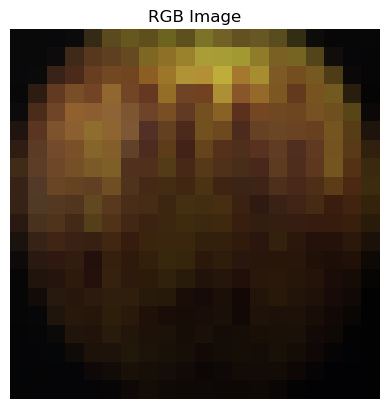

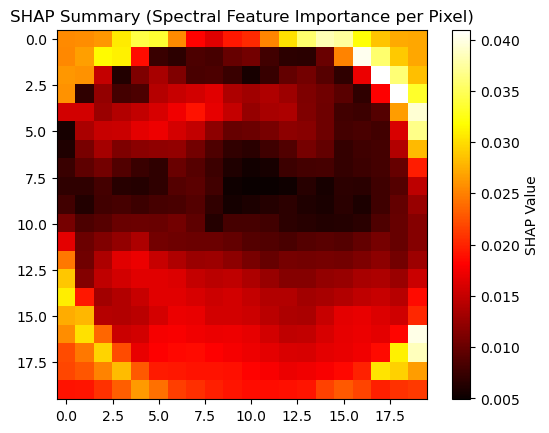

(20, 20, 204)


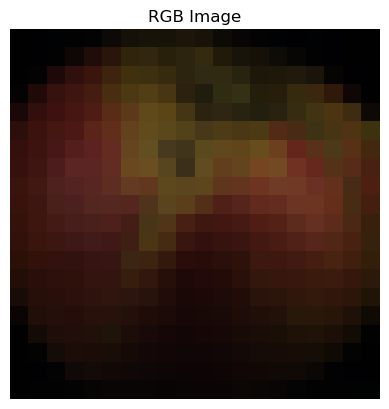

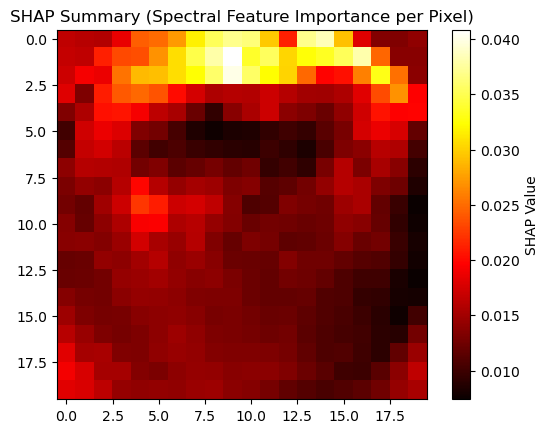

(20, 20, 204)


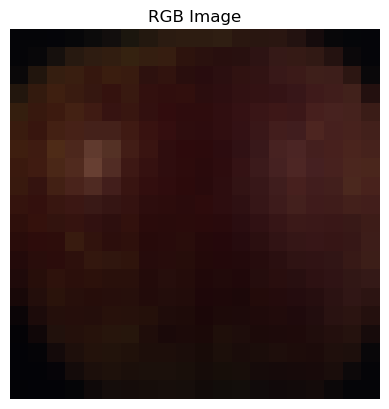

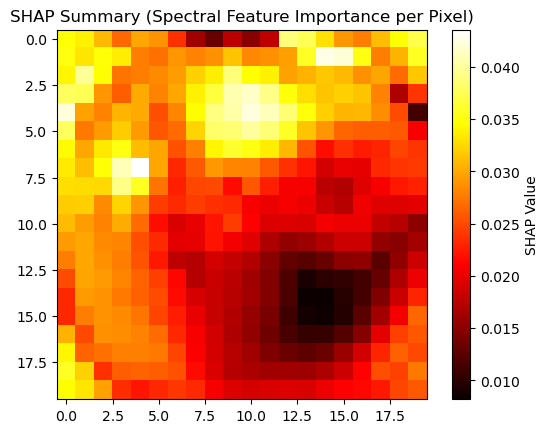

(20, 20, 204)


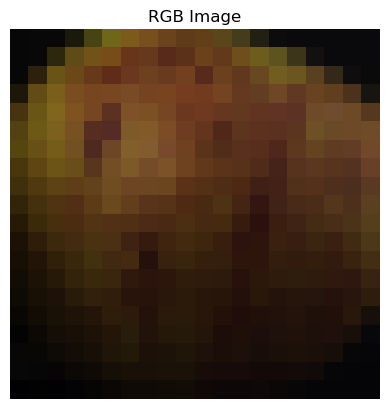

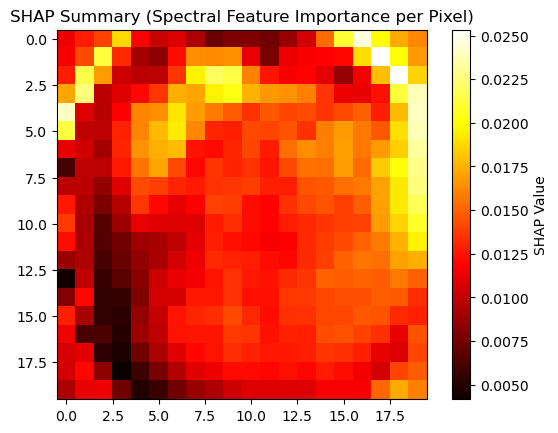

(20, 20, 204)


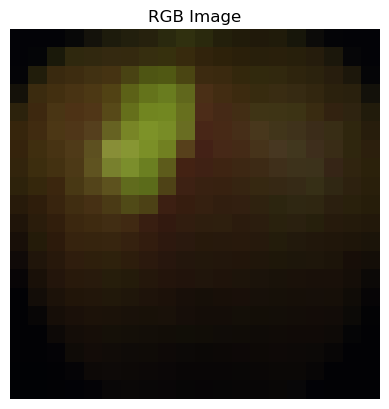

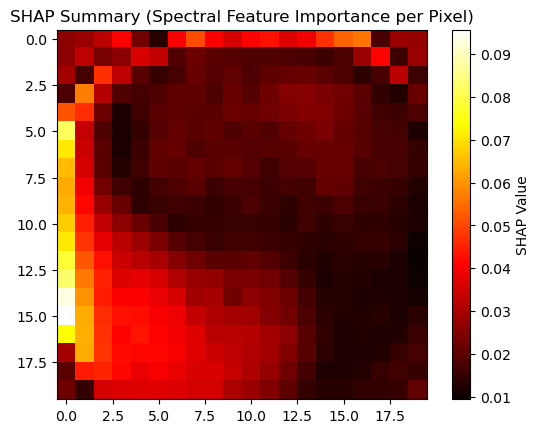

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


(20, 20, 204)


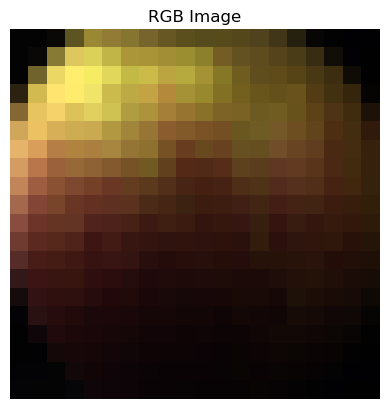

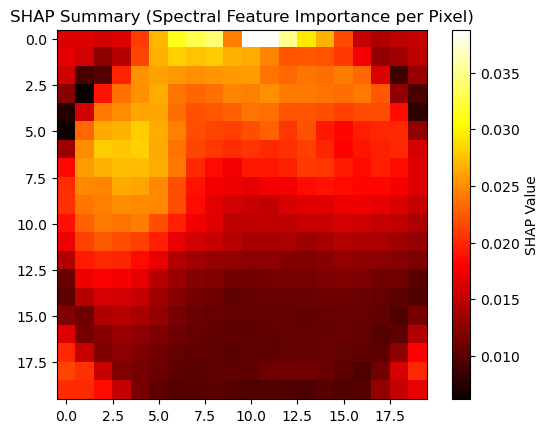

(20, 20, 204)


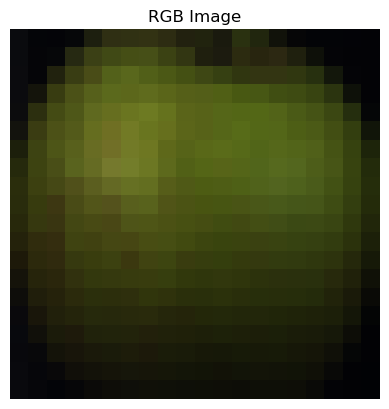

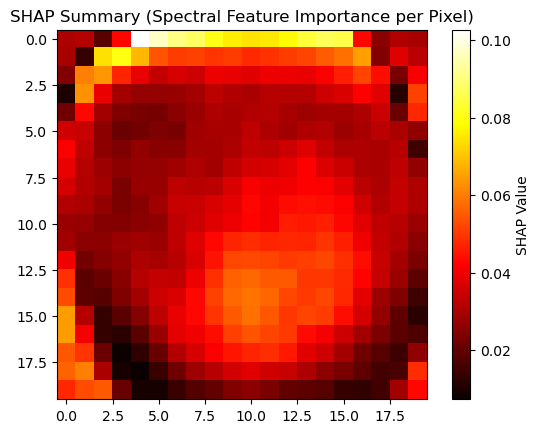

(20, 20, 204)


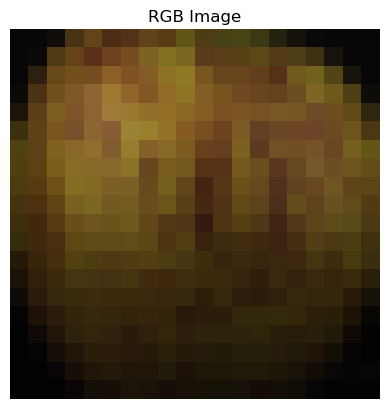

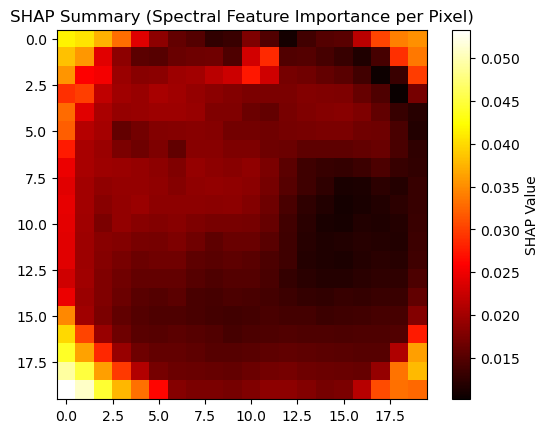

(20, 20, 204)


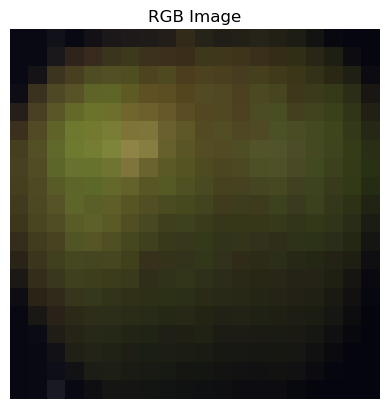

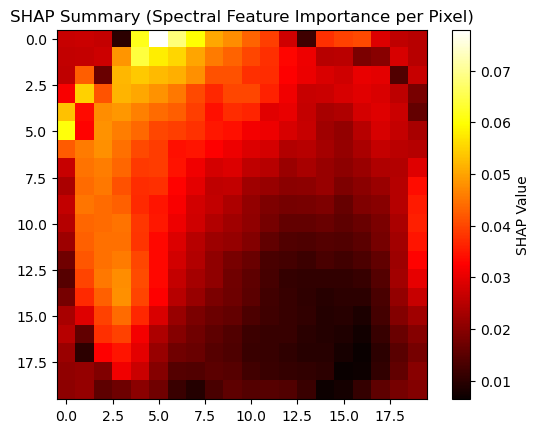

(20, 20, 204)


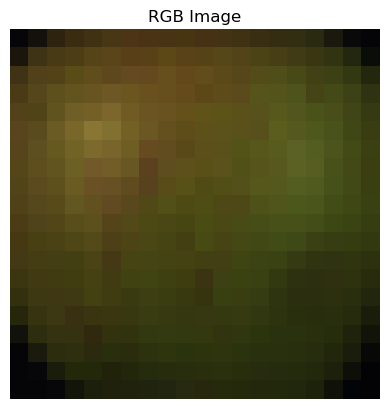

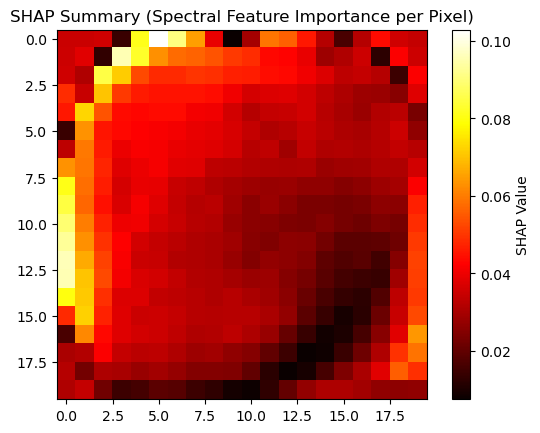

(20, 20, 204)


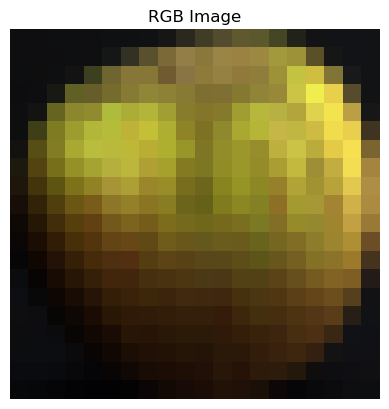

KeyboardInterrupt: 

In [18]:
# Looking at the importance of each pixel - one image at a time

# sample_idx = list(range(len(X_train[0])))

# for sample_num in sample_idx:
#     # if sample_num % 1000 == 0:
#     original_RGB_img = np.load(X_train[sample_num])
#     print(original_RGB_img.shape)
#     red_band = original_RGB_img[:, :, 69]
#     green_band = original_RGB_img[:, :, 52]
#     blue_band = original_RGB_img[:, :, 18]
#     rgb_image = np.stack([red_band, green_band, blue_band], axis=-1)
#     # Display image
#     plt.imshow(rgb_image)
#     plt.axis("off")
#     plt.title("RGB Image")
#     plt.show()

#     # for a single sample
#     shap_img = brix_shap_values.values[sample_num, :, :, :204] # Exclude the cultivar information for now
#     # print(type(shap_img))
#     input_img = sample_dat[[sample_num], :, :, :204]  
    
#     # Summarise across spectral bands
#     shap_summary = np.sum(np.abs(shap_img), axis=2)  # Shape: (img_size, img_size)
#     # print(shap_summary.shape)
#     # print(shap_summary)
#     plt.imshow(shap_summary, cmap='hot')
#     plt.title("SHAP Summary (Spectral Feature Importance per Pixel)")
#     plt.colorbar(label="SHAP Value")
#     plt.show()


In [101]:

def calculate_mean_shap_summary(shap_values, img_size=20):
    """
    Calculate the mean SHAP summary for the given SHAP values.

    Parameters:
    shap_values (np.array): SHAP values array with shape (num_samples, img_size, img_size, num_bands).
    img_size (int): Size of the image (default is 20).

    Returns:
    np.array: Mean SHAP summary with shape (img_size, img_size).
    """
    mean_shap_summary = np.zeros((img_size, img_size))
    sample_idx = list(range(len(shap_values)))

    for sample_num in sample_idx:
        shap_img = shap_values[sample_num, :, :, :204]
        shap_summary = np.sum(np.abs(shap_img), axis=2) # Shape: (img_size, img_size, 1)
        shap_summary_flattened = np.squeeze(shap_summary) # Shape: (img_size, img_size)
        mean_shap_summary += shap_summary_flattened

    mean_shap_summary /= len(sample_idx)
    return mean_shap_summary



def plot_heat_map(mean_shap_summary, label):
    """
    Plot a heat map of the mean SHAP summary with a label.

    Parameters:
    mean_shap_summary (np.array): Mean SHAP summary with shape (img_size, img_size).
    label (str): Label for the heat map.
    """
    plt.imshow(mean_shap_summary, cmap='hot')
    plt.text(-0.1, 1.05, label, transform=plt.gca().transAxes, fontsize=14, fontweight='bold', va='top', ha='left', bbox=dict(facecolor='white', alpha=0.8))
    plt.colorbar(label="Mean SHAP Value")
    plt.axis('off')



In [ ]:

mean_brix_shap_summary = calculate_mean_shap_summary(brix_shap_values.values, img_size)
mean_starch_shap_summary = calculate_mean_shap_summary(starch_shap_values.values, img_size)
mean_firmness_shap_summary = calculate_mean_shap_summary(firmness_shap_values.values, img_size)



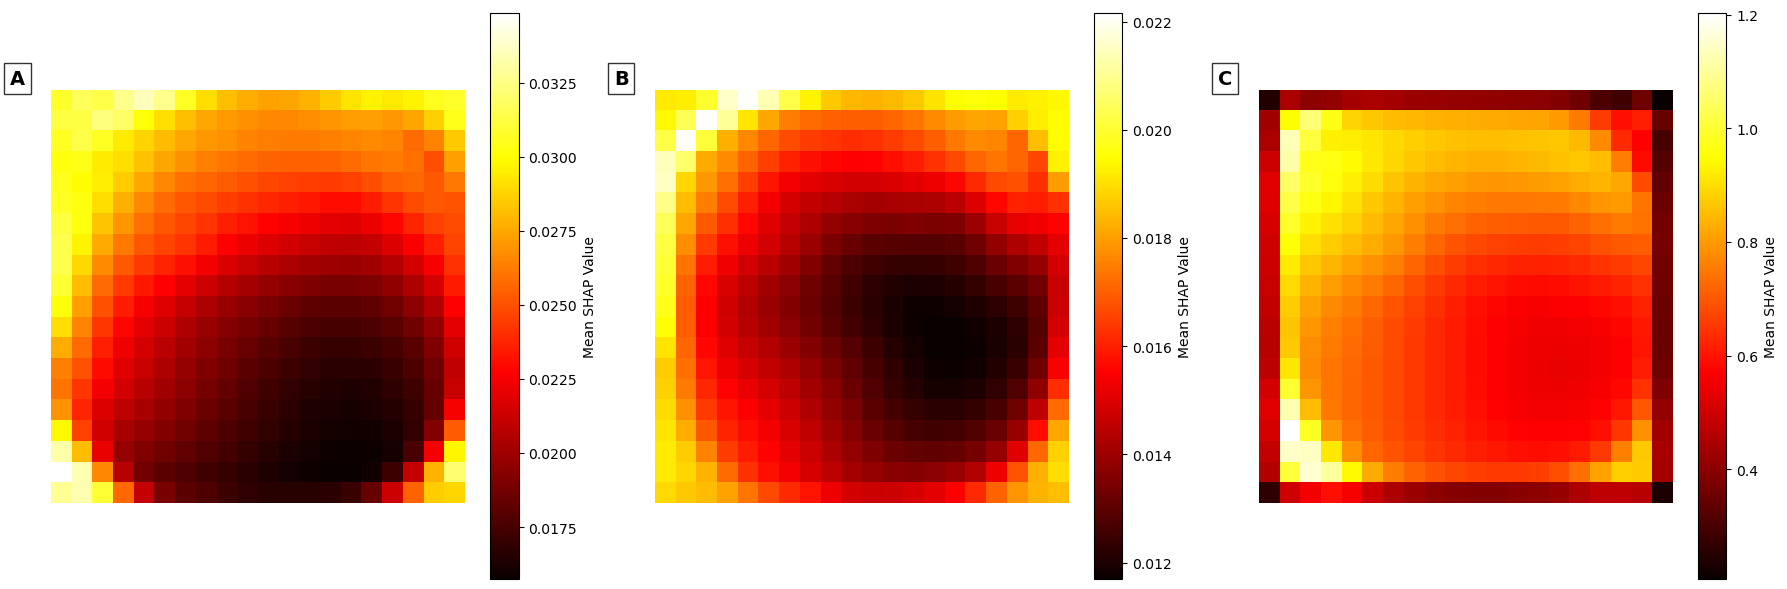

In [104]:


# Plot heat maps with labels A, B, and C
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plot_heat_map(mean_brix_shap_summary, "A")

plt.subplot(1, 3, 2)
plot_heat_map(mean_firmness_shap_summary, "B")

plt.subplot(1, 3, 3)
plot_heat_map(mean_starch_shap_summary, "C")


plt.tight_layout()
plt.show()



(20, 20)


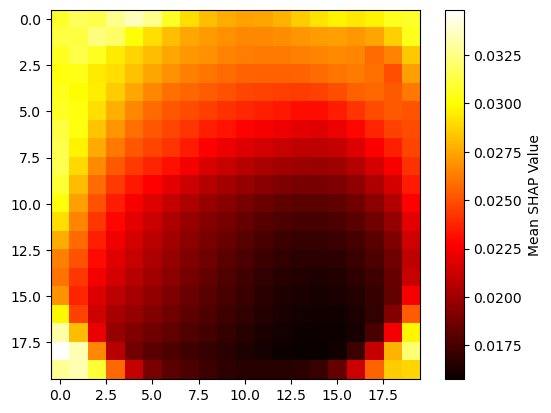

In [94]:
# Getting the average shap value for each pixel across all the samples then creating a heat map

img_size = 20

# intialise empty array
mean_shap_summary = np.zeros((img_size, img_size))

# Loop through all the samples
sample_idx = list(range(len(X_train)))

for sample_num in sample_idx:
    shap_img = brix_shap_values.values[sample_num, :, :, :204]
    # input_img = sample_dat[[sample_num], :, :, :204]
    shap_summary = np.sum(np.abs(shap_img), axis=2)
    # print(shap_summary[0])
    shap_summary_flattened = shap_summary[:,:,0]
    # print(shap_summary_flattened[0])
    # accumulate shap values
    mean_shap_summary += shap_summary_flattened

mean_shap_summary /= len(sample_idx)

print(mean_shap_summary.shape)
plt.imshow(mean_shap_summary, cmap = 'hot')
# plt.title("Mean SHAP Values per Pixel")
plt.colorbar(label="Mean SHAP Value")
plt.show()




In [71]:
# wavebands from Specim IQ camera

wavebands = ['397.32', '400.20', '403.09', '405.97', '408.85', '411.74', '414.63', '417.52', '420.40', '423.29', '426.19', '429.08', '431.97', '434.87', '437.76', '440.66', '443.56', '446.45', '449.35', '452.25', '455.16', '458.06', '460.96', '463.87', '466.77', '469.68', '472.59', '475.50', '478.41', '481.32', '484.23', '487.14', '490.06', '492.97', '495.89', '498.80', '501.72', '504.64', '507.56', '510.48', '513.40', '516.33', '519.25', '522.18', '525.10', '528.03', '530.96', '533.89', '536.82', '539.75', '542.68', '545.62', '548.55', '551.49', '554.43', '557.36', '560.30', '563.24', '566.18', '569.12', '572.07', '575.01', '577.96', '580.90', '583.85', '586.80', '589.75', '592.70', '595.65', '598.60', '601.55', '604.51', '607.46', '610.42', '613.38', '616.34', '619.30', '622.26', '625.22', '628.18', '631.15', '634.11', '637.08', '640.04', '643.01', '645.98', '648.95', '651.92', '654.89', '657.87', '660.84', '663.81', '666.79', '669.77', '672.75', '675.73', '678.71', '681.69', '684.67', '687.65', '690.64', '693.62', '696.61', '699.60', '702.58', '705.57', '708.57', '711.56', '714.55', '717.54', '720.54', '723.53', '726.53', '729.53', '732.53', '735.53', '738.53', '741.53', '744.53', '747.54', '750.54', '753.55', '756.56', '759.56', '762.57', '765.58', '768.60', '771.61', '774.62', '777.64', '780.65', '783.67', '786.68', '789.70', '792.72', '795.74', '798.77', '801.79', '804.81', '807.84', '810.86', '813.89', '816.92', '819.95', '822.98', '826.01', '829.04', '832.07', '835.11', '838.14', '841.18', '844.22', '847.25', '850.29', '853.33', '856.37', '859.42', '862.46', '865.50', '868.55', '871.60', '874.64', '877.69', '880.74', '883.79', '886.84', '889.90', '892.95', '896.01', '899.06', '902.12', '905.18', '908.24', '911.30', '914.36', '917.42', '920.48', '923.55', '926.61', '929.68', '932.74', '935.81', '938.88', '941.95', '945.02', '948.10', '951.17', '954.24', '957.32', '960.40', '963.47', '966.55', '969.63', '972.71', '975.79', '978.88', '981.96', '985.05', '988.13', '991.22', '994.31', '997.40', '1000.49', '1003.58']


def convert_to_numeric(string_list):
    return [float(item) for item in string_list]

wavebands_numeric = convert_to_numeric(wavebands)



(204, 1)
(204, 1)


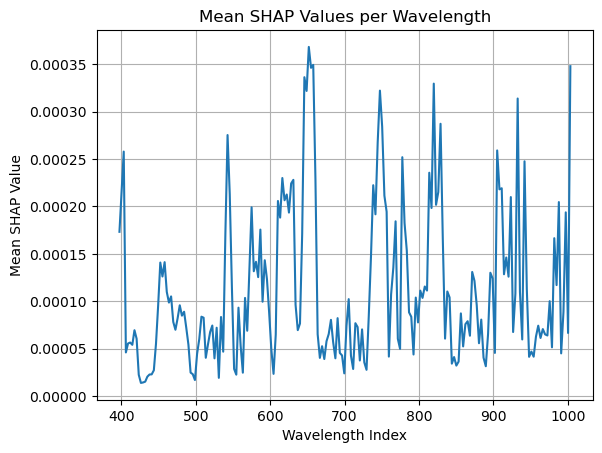

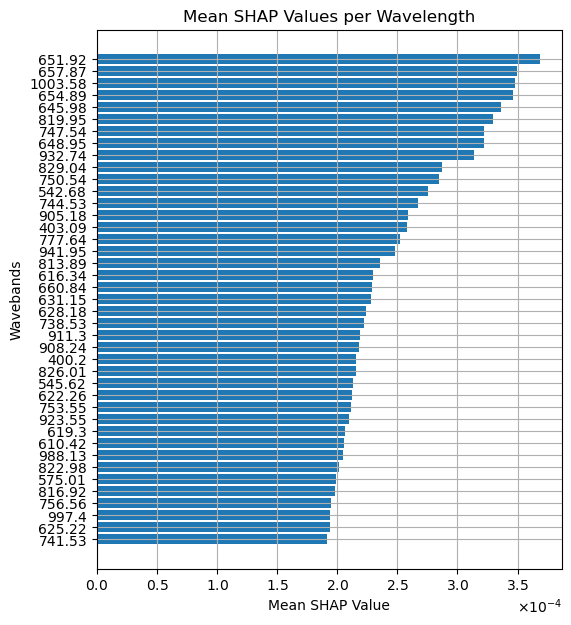

In [77]:
#Individual plots
mean_shap_per_band = np.mean(np.abs(brix_shap_values.values[:,:,:,:204]), axis=(0, 1, 2))  # Shape: (num_bands,)
print(mean_shap_per_band.shape)

mean_shap_per_band_flattened = mean_shap_per_band.flatten()

threshold = np.percentile(mean_shap_per_band_flattened, 80) # keep top 20% of the values
selected_features_threshold = mean_shap_per_band_flattened > threshold
# selected_features_threshold = selected_features_threshold.flatten()
filtered_spectra_data = mean_shap_per_band_flattened[selected_features_threshold]
# filtered_spectra_data = filtered_spectra_data.flatten()
filtered_wavebands = np.array(wavebands_numeric)[selected_features_threshold]


sorted_indices = np.argsort(filtered_spectra_data)[::1] #[::-1] for descending order
# print(sorted_indices)
sorted_filtered_spectra_data = filtered_spectra_data[sorted_indices]
sorted_filtered_wavebands = np.array(filtered_wavebands)[sorted_indices]

mean_shap_per_band = np.mean(np.abs(brix_shap_values.values[:,:,:,:204]), axis=(0, 1, 2))  # Shape: (num_bands,)
print(mean_shap_per_band.shape)

plt.plot(wavebands_numeric, mean_shap_per_band)
plt.title("Mean SHAP Values per Wavelength")
plt.xlabel("Wavelength Index")
plt.ylabel("Mean SHAP Value")
plt.grid(True)
plt.show()

  # Create a bar plot for the sorted mean SHAP values
plt.figure(figsize=(6, 7))
plt.barh(range(len(sorted_filtered_spectra_data)), sorted_filtered_spectra_data)
plt.yticks(range(len(sorted_filtered_spectra_data)), sorted_filtered_wavebands, rotation='horizontal')
plt.title("Mean SHAP Values per Wavelength")
plt.ylabel("Wavebands")
plt.xlabel("Mean SHAP Value")
plt.gca().xaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
plt.gca().ticklabel_format(style='sci', axis='x', scilimits=(0,0))
plt.grid(True)
plt.show() 

In [127]:
import pickle
# Get the indices of the selected wavelengths for each feature at 20%, 50% and 80%

#brix
mean_shap_per_band_brix = np.mean(np.abs(brix_shap_values.values[:,:,:,:204]), axis=(0, 1, 2))  # Shape: (num_bands,)

mean_shap_per_band_flattened_brix = mean_shap_per_band_brix.flatten()

threshold = np.percentile(mean_shap_per_band_flattened_brix, 80) # keep top 20% of the values
selected_features_threshold_brix_20 = mean_shap_per_band_flattened_brix > threshold
threshold = np.percentile(mean_shap_per_band_flattened_brix, 50) # keep top 50% of the values
selected_features_threshold_brix_50 = mean_shap_per_band_flattened_brix > threshold
threshold = np.percentile(mean_shap_per_band_flattened_brix, 20) # keep top 80% of the values
selected_features_threshold_brix_80 = mean_shap_per_band_flattened_brix > threshold


#firmness
mean_shap_per_band_firmness = np.mean(np.abs(firmness_shap_values.values[:,:,:,:204]), axis=(0, 1, 2))  # Shape: (num_bands,)

mean_shap_per_band_flattened_firmness = mean_shap_per_band_firmness.flatten()

threshold = np.percentile(mean_shap_per_band_flattened_firmness, 80) # keep top 20% of the values
selected_features_threshold_firmness_20 = mean_shap_per_band_flattened_firmness > threshold
threshold = np.percentile(mean_shap_per_band_flattened_firmness, 50) # keep top 50% of the values
selected_features_threshold_firmness_50 = mean_shap_per_band_flattened_firmness > threshold
threshold = np.percentile(mean_shap_per_band_flattened_firmness, 20) # keep top 80% of the values
selected_features_threshold_firmness_80 = mean_shap_per_band_flattened_firmness > threshold

#starch
mean_shap_per_band_starch = np.mean(np.abs(starch_shap_values.values[:,:,:,:204]), axis=(0, 1, 2))  # Shape: (num_bands,)

mean_shap_per_band_flattened_starch = mean_shap_per_band_starch.flatten()

threshold = np.percentile(mean_shap_per_band_flattened_starch, 80) # keep top 20% of the values
selected_features_threshold_starch_20 = mean_shap_per_band_flattened_starch > threshold
threshold = np.percentile(mean_shap_per_band_flattened_starch, 50) # keep top 50% of the values
selected_features_threshold_starch_50 = mean_shap_per_band_flattened_starch > threshold
threshold = np.percentile(mean_shap_per_band_flattened_starch, 20) # keep top 80% of the values
selected_features_threshold_starch_80 = mean_shap_per_band_flattened_starch > threshold


#save the booleans 
data_to_save = {
    'selected_features_threshold_brix_20':selected_features_threshold_brix_20,
    'selected_features_threshold_brix_50':selected_features_threshold_brix_50,
    'selected_features_threshold_brix_80':selected_features_threshold_brix_80,
    'selected_features_threshold_firmness_20':selected_features_threshold_firmness_20,
    'selected_features_threshold_firmness_50':selected_features_threshold_firmness_50,
    'selected_features_threshold_firmness_80':selected_features_threshold_firmness_80,
    'selected_features_threshold_starch_20':selected_features_threshold_starch_20,
    'selected_features_threshold_starch_50':selected_features_threshold_starch_50,
    'selected_features_threshold_starch_80':selected_features_threshold_starch_80
}

save_path = '/home/ht21074/Auto_box_apples/Auto_box_apples/Source_folder/Pickle_files/Shap_values/Filtered_booleans/'
with open(f'{save_path}booleans.pkl', 'wb') as file:
    pickle.dump(data_to_save, file)

(204, 1)


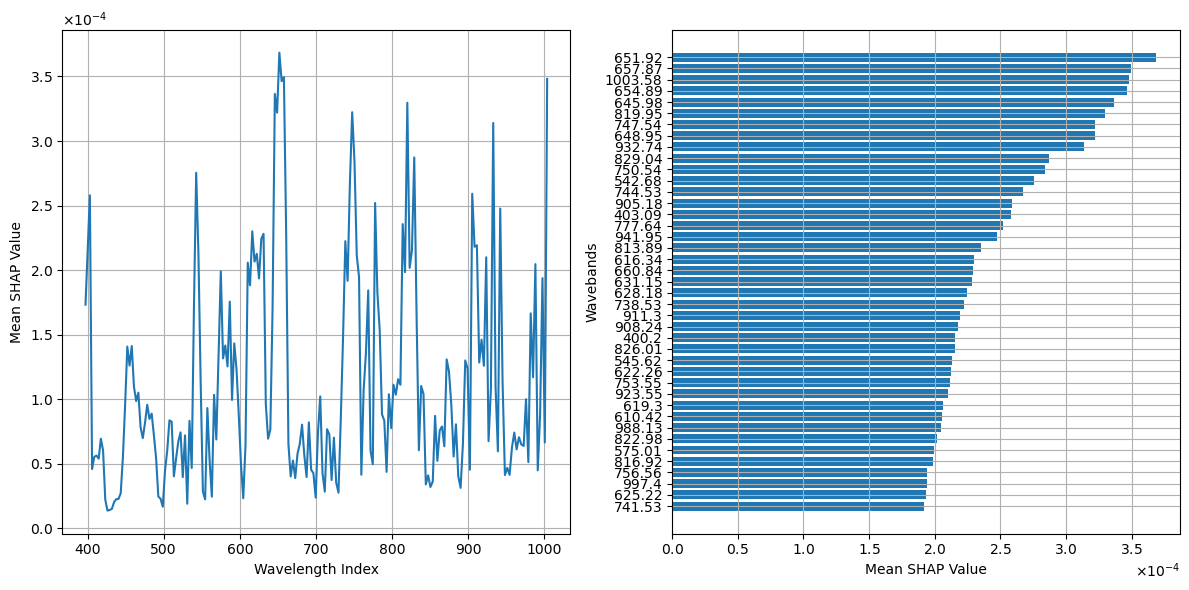

In [79]:
# Plot of all values across wavelengths and filtered values
# Flatten spatial dims and average over pixels and samples

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
mean_shap_per_band = np.mean(np.abs(brix_shap_values.values[:,:,:,:204]), axis=(0, 1, 2))  # Shape: (num_bands,)
print(mean_shap_per_band.shape)

ax1.plot(wavebands_numeric, mean_shap_per_band)
# ax1.set_title("Mean SHAP Values per Wavelength")
ax1.set_xlabel("Wavelength Index")
ax1.set_ylabel("Mean SHAP Value")
ax1.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
ax1.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax1.grid(True)



import matplotlib.ticker as ticker

# Create a summary plot to show the importance of each spectrum in decreasing order
# Sort the mean SHAP values and corresponding wavebands

mean_shap_per_band_flattened = mean_shap_per_band.flatten()

threshold = np.percentile(mean_shap_per_band_flattened, 80) # keep top 20% of the values
selected_features_threshold = mean_shap_per_band_flattened > threshold
# selected_features_threshold = selected_features_threshold.flatten()
filtered_spectra_data = mean_shap_per_band_flattened[selected_features_threshold]
# filtered_spectra_data = filtered_spectra_data.flatten()
filtered_wavebands = np.array(wavebands_numeric)[selected_features_threshold]


sorted_indices = np.argsort(filtered_spectra_data)[::1] #[::-1] for descending order
# print(sorted_indices)
sorted_filtered_spectra_data = filtered_spectra_data[sorted_indices]
sorted_filtered_wavebands = np.array(filtered_wavebands)[sorted_indices]

# Create a bar plot for the sorted mean SHAP values
# ax2.figure(figsize=(6, 7))
ax2.barh(range(len(sorted_filtered_spectra_data)), sorted_filtered_spectra_data)
ax2.set_yticks(range(len(sorted_filtered_spectra_data)), sorted_filtered_wavebands, rotation='horizontal')
# ax2.set_title("Mean SHAP Values per Wavelength top 20%")
ax2.set_ylabel("Wavebands")
ax2.set_xlabel("Mean SHAP Value")
ax2.xaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
ax2.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
ax2.grid(True)


plt.tight_layout()
plt.show()



In [123]:

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


def plot_shap_values(ax1, ax2, shap_values, wavebands_numeric, main_label, sublabel1, sublabel2):
    """
    Plot SHAP values across wavelengths and filtered values.

    Parameters:
    ax1 (matplotlib.axes._subplots.AxesSubplot): Axis for the first plot.
    ax2 (matplotlib.axes._subplots.AxesSubplot): Axis for the second plot.
    shap_values (np.array): SHAP values array with shape (num_samples, img_size, img_size, num_bands).
    wavebands_numeric (np.array): Array of wavebands.
    main_label (str): Main label for the plot (e.g., '1', '2', '3').
    sublabel1 (str): Sublabel for the first subplot (e.g., 'A').
    sublabel2 (str): Sublabel for the second subplot (e.g., 'B').
    """
    # Flatten spatial dims and average over pixels and samples
    mean_shap_per_band = np.mean(np.abs(shap_values[:,:,:,:204]), axis=(0, 1, 2)) # Shape: (num_bands,)
    print(mean_shap_per_band.shape)

    # Plot of all values across wavelengths
    ax1.plot(wavebands_numeric, mean_shap_per_band)
    ax1.set_xlabel("Wavelength Index")
    ax1.set_ylabel("Mean SHAP Value")
    ax1.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
    ax1.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    ax1.grid(True)
    ax1.text(-0.1, 1.05, f"{main_label}{sublabel1}", transform=ax1.transAxes, fontsize=14, fontweight='bold', va='top', ha='left', bbox=dict(facecolor='white', alpha=0.8))

    # Create a summary plot to show the importance of each spectrum in decreasing order
    mean_shap_per_band_flattened = mean_shap_per_band.flatten()
    threshold = np.percentile(mean_shap_per_band_flattened, 80) # keep top 20% of the values
    selected_features_threshold = mean_shap_per_band_flattened > threshold
    filtered_spectra_data = mean_shap_per_band_flattened[selected_features_threshold]
    filtered_wavebands = np.array(wavebands_numeric)[selected_features_threshold]

    sorted_indices = np.argsort(filtered_spectra_data)[::1] # Sort in ascending order
    sorted_filtered_spectra_data = filtered_spectra_data[sorted_indices]
    sorted_filtered_wavebands = np.array(filtered_wavebands)[sorted_indices]

    # Create a bar plot for the sorted mean SHAP values
    ax2.barh(range(len(sorted_filtered_spectra_data)), sorted_filtered_spectra_data)
    ax2.set_yticks(range(len(sorted_filtered_spectra_data)), sorted_filtered_wavebands, rotation='horizontal')
    ax2.set_ylabel("Wavebands")
    ax2.set_xlabel("Mean SHAP Value")
    ax2.xaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
    ax2.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
    ax2.grid(True)
    ax2.text(-0.1, 1.05, f"{main_label}{sublabel2}", transform=ax2.transAxes, fontsize=14, fontweight='bold', va='top', ha='left', bbox=dict(facecolor='white', alpha=0.8))



(204, 1)
(204, 1)
(204, 1)


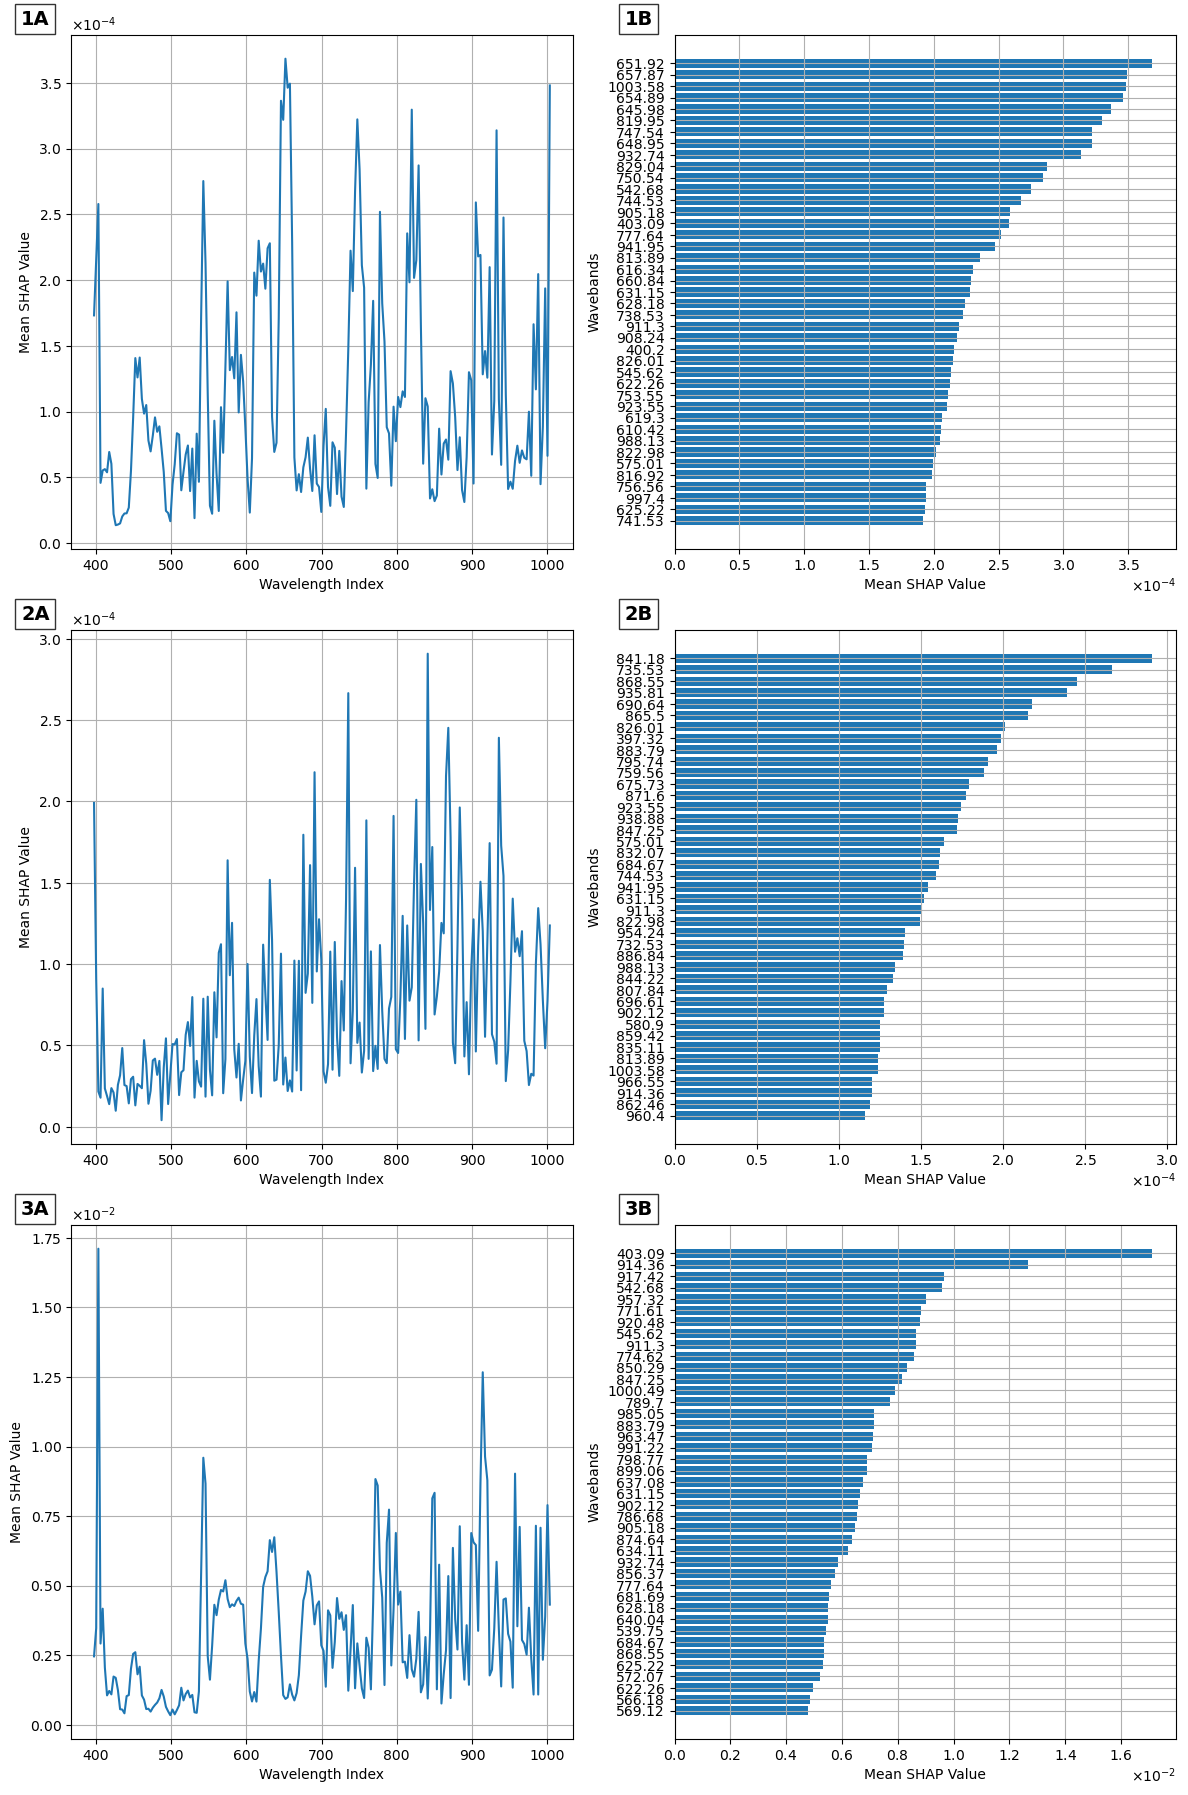

In [124]:

# Plot SHAP values for Brix, Starch, and Firmness in a single figure
fig, axes = plt.subplots(3, 2, figsize=(12, 18))

# Brix
plot_shap_values(axes[0, 0], axes[0, 1], brix_shap_values.values, wavebands_numeric, "1", "A", "B")

# Firmness
plot_shap_values(axes[1, 0], axes[1, 1], firmness_shap_values.values, wavebands_numeric, "2", "A", "B")

# Starch
plot_shap_values(axes[2, 0], axes[2, 1], starch_shap_values.values, wavebands_numeric, "3", "A", "B")

plt.tight_layout()
plt.show()


In [57]:
mean_shap_per_band_flattened = mean_shap_per_band.flatten()
sorted_indices = np.argsort(mean_shap_per_band_flattened)[::2]
print(sorted_indices)
sorted_mean_shap_per_band = mean_shap_per_band_flattened[sorted_indices]
sorted_wavebands_numeric = np.array(wavebands_numeric)[sorted_indices]

print(sorted_mean_shap_per_band)

[ 10  12  46   9  14  34 103  33 113  53 153 112 110  44  92 165 185 123
 102  36 101   3 186 128 156  56  32  17 163  98 182 127 148 188 193 192
  96 202  42   7  26 191  31 104  43  83 136 158 164 100  47  38  29  69
 200  55  28  81  66 105 138 150 124 181 149 140  52 197  68  64  20 168
  62 125  21  67 115 147  84   0 130  74  78 122  61 198  76 121  51   1
 173  79  90 141 129 171  50 146  86 143  88  89]
[1.36662885e-05 1.50155630e-05 1.90217042e-05 2.22201274e-05
 2.25691800e-05 2.28882553e-05 2.37552791e-05 2.45718890e-05
 2.75287471e-05 2.84660337e-05 3.19581761e-05 3.53547471e-05
 3.73511524e-05 3.96129355e-05 4.01164507e-05 4.03705098e-05
 4.12165316e-05 4.14622024e-05 4.26846894e-05 4.43952742e-05
 4.53185516e-05 4.58649544e-05 4.67453240e-05 4.96046591e-05
 5.22043040e-05 5.25818993e-05 5.40867983e-05 5.49845861e-05
 5.55809712e-05 5.66218343e-05 5.95648644e-05 6.02461087e-05
 6.04427006e-05 6.24905564e-05 6.37743982e-05 6.49214118e-05
 6.53299196e-05 6.64202014e-05 6.742

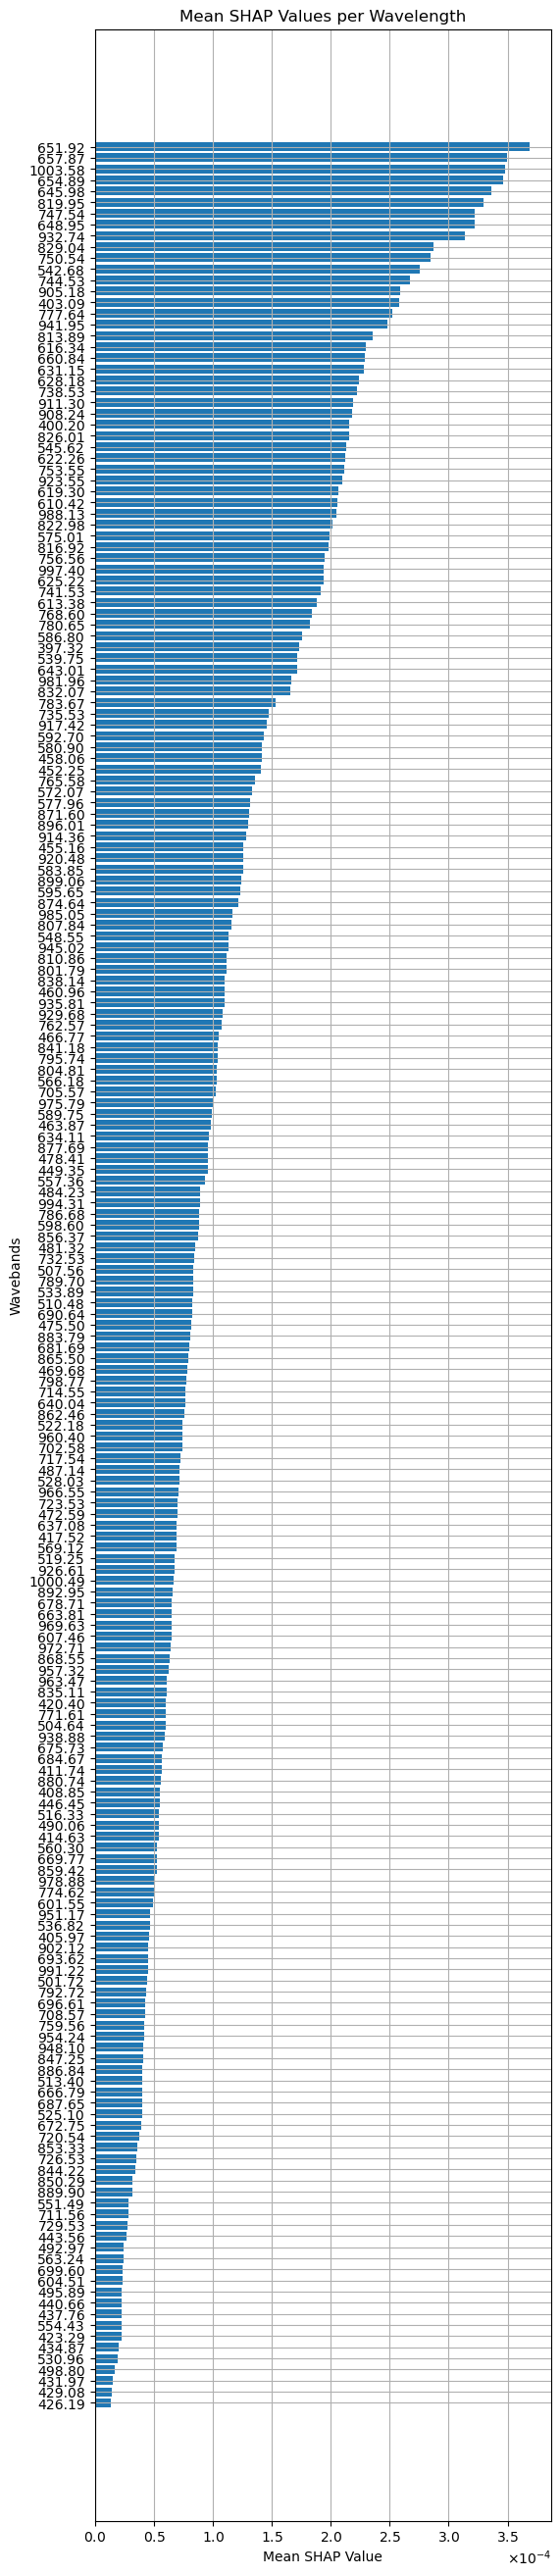

In [125]:
# All the spectra


sorted_indices_all = np.argsort(mean_shap_per_band_flattened)[::1]
sorted_spectra_data = mean_shap_per_band_flattened[sorted_indices_all]
sorted_spectra_data_flattened = sorted_spectra_data.flatten()
sorted_wavebands = np.array(wavebands)[sorted_indices_all]


# Create a bar plot for the sorted mean SHAP values
plt.figure(figsize=(6, 33))
plt.barh(range(len(sorted_spectra_data_flattened)), sorted_spectra_data_flattened)
plt.yticks(range(len(sorted_spectra_data_flattened)), sorted_wavebands, rotation='horizontal')
plt.title("Mean SHAP Values per Wavelength")
plt.ylabel("Wavebands")
plt.xlabel("Mean SHAP Value")
plt.gca().xaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
plt.gca().ticklabel_format(style='sci', axis='x', scilimits=(0,0))
plt.grid(True)
plt.show()

(9686, 6, 1)
[1.40298556e-03 2.69454531e-04 2.26022582e-03 7.09851521e-04
 6.78627167e-04 1.46153902e-05]


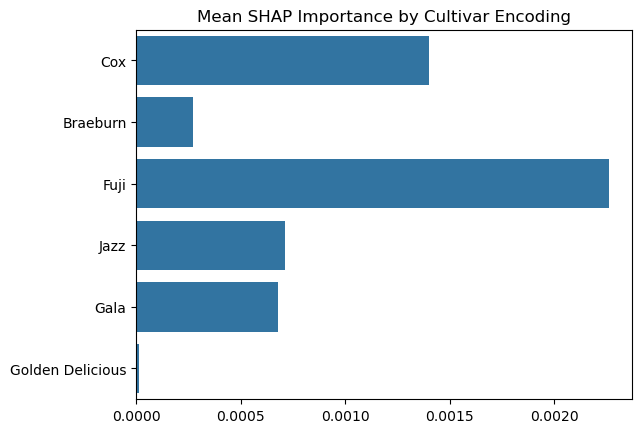

In [80]:
# Visualise cultivar importance

cultivar_shap = brix_shap_values.values[:, 0, 0,204:] # first pixel, any will do

print(cultivar_shap.shape)

mean_cultivar_importance = np.mean(np.abs(cultivar_shap), axis=(0, 2))   

print(mean_cultivar_importance)

import seaborn as sns

cultivars = ['Cox', 'Braeburn', 'Fuji', 'Jazz', 'Gala', 'Golden Delicious']

sns.barplot(x=mean_cultivar_importance, y=cultivars)
plt.title("Mean SHAP Importance by Cultivar Encoding")
plt.show()


In [4]:
save_path = '/home/ht21074/Auto_box_apples/Auto_box_apples/Source_folder/Pickle_files/Shap_values/Filtered_booleans/'
with open(f'{save_path}booleans.pkl', 'rb') as file:
    loaded_data = pickle.load(file)


selected_features_threshold_brix_20 = loaded_data['selected_features_threshold_brix_20']
selected_features_threshold_brix_50 = loaded_data['selected_features_threshold_brix_50']
selected_features_threshold_brix_80 = loaded_data['selected_features_threshold_brix_80']
selected_features_threshold_firmness_20 = loaded_data['selected_features_threshold_firmness_20']
selected_features_threshold_firmness_50 = loaded_data['selected_features_threshold_firmness_50']
selected_features_threshold_firmness_80 = loaded_data['selected_features_threshold_firmness_80']
selected_features_threshold_starch_20 = loaded_data['selected_features_threshold_starch_20']
selected_features_threshold_starch_50 = loaded_data['selected_features_threshold_starch_50']
selected_features_threshold_starch_80 = loaded_data['selected_features_threshold_starch_80']


print(selected_features_threshold_firmness_80)

waveband_count = sum(selected_features_threshold_firmness_80)
print(waveband_count)

FileNotFoundError: [Errno 2] No such file or directory: '/home/ht21074/Auto_box_apples/Auto_box_apples/Source_folder/Pickle_files/Shap_values/Filtered_booleans/booleans.pkl'

In [5]:
import numpy as np
img_size = 40
if img_size == 30 or img_size == 20:
    training_data_path = '/home/ht21074/Auto_box_apples/Auto_box_apples/Source_folder/Training_data_May2025/30px/all_years/'
elif img_size == 50 or img_size ==40:
    training_data_path = '/home/ht21074/Auto_box_apples/Auto_box_apples/Source_folder/Training_data_May2025/50px/all_years/'


X_train_brix          = np.load(f'{training_data_path}X_train_all_years_Brix_shuffled.npy')
# print(X_train_brix)
Y_train_brix          = np.load(f'{training_data_path}Y_train_all_years_Brix_shuffled.npy')
X_validate_brix       = np.load(f'{training_data_path}X_validate_all_years_Brix_shuffled.npy')
Y_validate_brix       = np.load(f'{training_data_path}Y_validate_all_years_Brix_shuffled.npy')
Frmness_encoder_shuffled  = np.load(f'{training_data_path}X_train_all_years_Brix_encoder_shuffled.npy')
validate_encoder        = np.load(f'{training_data_path}X_validate_all_years_Brix_encoder_shuffled.npy')

spectral_path = '/media/2tbdisk3/data/Haidee/May_2025_spectral_img/Spectral/'

X_train_brix = [spectral_path + file for file in X_train_brix]


X_train_brix = X_train_brix[:1]


In [6]:
print(X_train_brix)

['/media/2tbdisk3/data/Haidee/May_2025_spectral_img/Spectral/50px/NZ2024/50px_Braeburn_1453_7768.npy']


In [7]:
import pickle     
band_filter = 20
boolean_path = '/home/ht21074/Auto_box_apples/Auto_box_apples/Source_folder/Pickle_files/Shap_values/May2025/Filtered_booleans/'
with open(f'{boolean_path}booleans.pkl', 'rb') as file:
    loaded_data = pickle.load(file)

if band_filter == 20:
    print("Using 20% of the features")
    selected_features_threshold_brix = loaded_data['selected_features_threshold_brix_20']
    selected_features_threshold_firmness = loaded_data['selected_features_threshold_firmness_20']
    selected_features_threshold_starch = loaded_data['selected_features_threshold_starch_20']
elif band_filter == 50:
    print("Using 50% of the features")
    selected_features_threshold_brix = loaded_data['selected_features_threshold_brix_50']
    selected_features_threshold_firmness = loaded_data['selected_features_threshold_firmness_50']
    selected_features_threshold_starch = loaded_data['selected_features_threshold_starch_50']
elif band_filter == 80:
    print("Using 80% of the features")
    selected_features_threshold_brix = loaded_data['selected_features_threshold_brix_80']
    selected_features_threshold_firmness = loaded_data['selected_features_threshold_firmness_80']
    selected_features_threshold_starch = loaded_data['selected_features_threshold_starch_80']

Using 20% of the features


In [8]:
def data_generator_w_cultivar(file_list, targets, cultivars, batch_size, img_size, band_filter=None):
    num_samples = len(file_list)
    missing_files = [] # List of missing files

    while True:  # Infinite loop for generator
        for offset in range(0, num_samples, batch_size):
            # Load the batch of data from file paths
            batch_files = file_list[offset: offset + batch_size]
            batch_data = []
            batch_targets = []
            batch_cultivars = []

            # File loading and handling - ensures model runs if file not found
            for i, file in enumerate(batch_files):
                try:
                    data = np.load(file)
                    if img_size == 40 or img_size ==20:
                        data_reduced = data[5:-5, 5:-5, :] # Remove 5 pixels from each edge
                        batch_data.append(data_reduced)
                    else:                    
                        batch_data.append(data)
                    batch_targets.append(targets[offset + i])
                    batch_cultivars.append(cultivars[offset + i])
                except FileNotFoundError:
                    missing_files.append(file)
                    #print(f"File not found: {file}. Skipping...")
                    continue
            

            # Convert lists to numpy arrays
            batch_data = np.array(batch_data)  # Shape: (batch_size, 20, 20, 204)
            batch_targets = np.array(batch_targets)  # Shape: (batch_size,)
            batch_cultivars = np.array(batch_cultivars)  # Shape: (batch_size, 6)
            
            if len(batch_data) == 0:
                continue # Skip if no data loaded

            # Filter some spectral bands if needed
            if band_filter is not None:

                filtered_test = batch_data[:, :, :, band_filter] # % of the features for brix

                batch_data = filtered_test
            
                       
            # Expand cultivar information to match the input data's spatial dimensions
            expanded_cultivars = np.repeat(batch_cultivars[:, np.newaxis, np.newaxis, :], img_size, axis=1) # Adds singleton dimensions to match the input data's spatial dimensions (batchsize, 1, 1, 1, 6)
            expanded_cultivars = np.repeat(expanded_cultivars, img_size, axis=2)

            # Concatenate cultivar information with the original data along the last axis
            combined_data = np.concatenate([batch_data, expanded_cultivars], axis=-1)  # Shape: (batch_size, 20, 20, 210)

            # Yield the combined data and targets
            return combined_data, batch_targets

        # After the loop, print and save the missing files
        if missing_files:
            print(f"Missing files: {missing_files}")
            missing_files = []  # Clear the list after saving


In [9]:
batch_size= 1
train_generator = data_generator_w_cultivar(X_train_brix, Y_train_brix, Frmness_encoder_shuffled, batch_size, img_size=img_size, band_filter =selected_features_threshold_brix)

In [10]:
print(train_generator[0].shape)

(1, 40, 40, 47)
